In [1]:
%reload_ext autoreload
%autoreload 2

from numba import jit,njit
import time
from multiprocessing import Process,Pool, Queue, Manager, get_context

import os
import sys
module_path = os.path.abspath(os.path.join('atmospherics-tools/fast-osc-feedback')) 
sys.path.insert(0, module_path)
print(module_path)
# import all the functions from the fastfeedback module
from fastfeedback import *

/home/raphael/Bureau/travail/stage_apc/code-extrait/atmospherics-tools/fast-osc-feedback/atmospherics-tools/fast-osc-feedback
Welcome to JupyROOT 6.28/04


cling::DynamicLibraryManager::loadLibrary(): ../oscprob-src/lib/libOscProb.so: cannot open shared object file: No such file or directory


In [2]:
# A hand made tool to monitor time execution (better tools do exist in already implemented packages ;p)

temps = {}

def chrono(func):
    def aux(*param):
        start = time.time()
        func(*param)
        end = time.time()
        print(f"Fonction {func.__name__} : {end-start:e} s")

        if func in temps :
            temps[func]["temps tot"] += end-start
            temps[func]["nb"] += 1
        else :
            temps[func] = {"temps tot" : end-start, "nb" : 1}
    
    return aux

@chrono
def func(bu):
    print(bu)

func("bu")

bu
Fonction func : 2.036095e-04 s


In [3]:
#Loading the CAFs data
if not ("data_manager" in globals().keys() and isinstance(data_manager, DataManager)):      # Avoid reloading the data if already done
    data_manager = DataManager("/home/raphael/Bureau/travail/stage_apc/code-extrait/atmospherics_prod_1M_events_cafs_hadd_with_weights.root")

Loading data...
Finished loading data


# I. Using the current reconstruction performance

In the article Neutrino Mass Ordering at DUNE: an Extra ν-Bonus (arXiv:1905.03589v2 [hep-ph] 22 Nov 2019),
the dependency of the absolute angle resolution wrt the energy is :

\begin{equation}
    \sigma_\theta = \frac{C}{E_\nu} + D
\end{equation}

with $C = 7.79 \ (\nu_\mu)$ and $D = 3.71 (\nu_\mu)$

In [4]:
# Perso angle smearing : absolute resolution on the angle (not sin(angle))
C = 7.79
D = 3.71

_C = {
    Flavor.NuMu : 7.79,
    Flavor.NuMuBar : 8.46,
    Flavor.NuE : 7.85,
    Flavor.NuEBar : 8.42
}

_D = {
    Flavor.NuMu : 3.71,
    Flavor.NuMuBar : 2.29,
    Flavor.NuE : 3.7,
    Flavor.NuEBar : 2.31
}

def Czfake_funcBins(bin_var_values : pl.Series, true_values, resolutions, bins):
    bin_sort = np.digitize(bin_var_values, bins)
    fake_values = np.arccos(true_values) + np.random.normal(0, resolutions[bin_sort])
    return np.cos(fake_values)

def Czfake_funcE(bin_var_values : pl.Series, true_values, energy_values, flavor=None):
    if flavor is None :
        fake_values = np.arccos(true_values) + np.random.normal(0,C/energy_values+D)*np.pi/180
    else :
        fake_values = np.arccos(true_values) + np.random.normal(0,[_C[fl]/energy_values+_D[fl] for fl in flavor])*np.pi/180
    return np.cos(fake_values)

In [5]:
Eres_events = 0.0
Eres_events2 = 0.0

Czres_events = 15*np.pi/180
Czres_events2 = 20*np.pi/180

In [6]:
eventsDict = Manager().dict()

def MultiEventDistrib(*args,nom):
    print("multiEvnt")
    res = EventDistrib(*args)
    print("dict")
    eventsDict[nom] = res
    print("fin")

def Pipo(*args,nom):
    eventsDict[nom] = "pipoté"

##### Matteo's binning (except Ebins_fake and Czbins_fake) :
``` python
Ebins = np.linspace(1,10,100)
Czbins = np.linspace(-1,0, 100)
Ebins_reco = np.linspace(1,10,20)
Czbins_reco = np.linspace(-1,0,20)

Ebins_fake = np.linspace(1,10,20)
Czbins_fake = np.linspace(-1,0,20)
```

##### Article's binning :

- energy : 12 bins between 2 and 8 GeV
- angle : 10 bins between 0 and -1

np.linspace(2,8,13)
np.linspace(-1,0,11)

In [7]:
#Defining the binning for the true and reco energy and coszenith
"""
Ebins = np.logspace(-1, 1, 50) #50 #100 #200
#Ebins = np.linspace(1, 8, 100)
Czbins = np.linspace(-1, 0, 20) #20 #50 #100
Ebins_reco = np.logspace(-1, 1, 20) #threshold 0.5 GeV
#Ebins_reco = np.linspace(0, 10, 20)
#Ebins_reco = np.linspace(0,10,50)
Czbins_reco = np.linspace(-1, 0, 20)

Ebins_fake = np.logspace(-1, 1, 50)
Czbins_fake = np.linspace(-1, 0, 50)

"""
Ebins = np.linspace(2, 8, 13)
Czbins = np.linspace(-1,0,11)

Ebins_reco = np.linspace(2, 8, 13)
Czbins_reco = np.linspace(-1,0,11)

Ebins_fake = np.linspace(2, 8, 13)
Czbins_fake = np.linspace(-1,0,11)


In [8]:
data_manager.set_direc_reco(Method.Truth)
data_manager.set_flavor_discrimination(Method.Truth)

Eres = np.ones(len(Ebins_fake)+1)*Eres_events #NO RESOLUTION 
shift = np.ones(len(Ebins_fake)+1)*0.00  #NO SHIFT
Czres = np.ones(len(Czbins_fake)+1)*Czres_events # RESOLUTION IN ZENITH ANGLE
Efake = FakeResolution(Ebins_fake, Eres, bin_var = pl.when(pl.col('nuPDG') == Flavor.NuMu).then(pl.col('recoE_numu')).otherwise(pl.col('recoE_nue')), shifts=shift)                       
Czfake = FakeResolution(Czbins_fake, Czres, bin_var = pl.when(pl.col('nuPDG') == Flavor.NuMu).then(pl.col('direc_numu')).otherwise(pl.col('direc_nue')))
data_manager.set_energy_reco(Method.Efficiency, Efake)

"""
data_manager.set_direc_reco(Method.Perso,
                            pl.lit(
                                Czfake_funcBins(data_manager.data.select(pl.when(pl.col('nuPDG') == Flavor.NuMu).then(pl.col('direc_numu')).otherwise(pl.col('direc_nue'))).to_series(),
                                            data_manager.data["direc_true"],Czres,Czbins_fake)))
"""
"""
data_manager.set_direc_reco(Method.Perso,
                            pl.lit(
                                Czfake_funcE(data_manager.data.select(pl.when(pl.col('nuPDG') == Flavor.NuMu).then(pl.col('direc_numu')).otherwise(pl.col('direc_nue'))).to_series(),
                                            data_manager.data["direc_true"],data_manager.data["Ev"])))
"""
data = data_manager.prepare_data()
#Creating the reference events distribution 
events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

"""
eventsProcess = Process(target=MultiEventDistrib,args=(data, Ebins, Czbins, Ebins_reco, Czbins_reco),kwargs={"nom":"events"})
eventsProcess.daemon = True
"""

shift = np.ones(len(Ebins_fake)+1)*0.0  # SHIFT 
for t,x in enumerate(Ebins_fake):
    shift[t]=Ebins_fake[t]*0.01 #1% shift up
    #print(Ebins_fake[t], shift[t])
    
Eres = np.ones(len(Ebins_fake)+1)*0.0  #1% smear RESOLUTION 
Efake = FakeResolution(Ebins_fake, Eres, bin_var = pl.when(pl.col('nuPDG') == Flavor.NuMu).then(pl.col('recoE_numu')).otherwise(pl.col('recoE_nue')), shifts=shift)                       
data_manager.set_energy_reco(Method.Efficiency, Efake)
data_manager.set_direc_reco(Method.Truth)

toydata = data_manager.prepare_data()  #-- modified by systematic effect
toyevents = EventDistrib(toydata, Ebins, Czbins, Ebins_reco, Czbins_reco)


shift = np.ones(len(Ebins_fake)+1)*0.0  #NO SHIFT
Eres = np.ones(len(Ebins_fake)+1)*Eres_events2 # RESOLUTION IN ENERGY
Czres = np.ones(len(Czbins_fake)+1)*Czres_events2 # RESOLUTION IN ZENITH ANGLE
Efake = FakeResolution(Ebins_fake, Eres, bin_var = pl.when(pl.col('nuPDG') == Flavor.NuMu).then(pl.col('recoE_numu')).otherwise(pl.col('recoE_nue')), shifts=shift)    
Czfake = FakeResolution(Czbins_fake, Czres, bin_var = pl.when(pl.col('nuPDG') == Flavor.NuMu).then(pl.col('direc_numu')).otherwise(pl.col('direc_nue')))                       
data_manager.set_energy_reco(Method.Efficiency, Efake)
data_manager.set_direc_reco(Method.Truth, Czfake)

"""
data_manager.set_direc_reco(Method.Perso,
                            pl.lit(
                                Czfake_funcBins(data_manager.data.select(pl.when(pl.col('nuPDG') == Flavor.NuMu).then(pl.col('direc_numu')).otherwise(pl.col('direc_nue'))).to_series(),
                                            data_manager.data["direc_true"],Czres,Czbins_fake)))
"""

data2 = data_manager.prepare_data()
events2 = EventDistrib(data2, Ebins, Czbins, Ebins_reco, Czbins_reco)

"""
print("start")
eventsProcess.start()
print("join")
eventsProcess.join()

events = eventsDict["events"]
print("terminate")
eventsProcess.terminate()
print("ok!")

"""


Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


AttributeError: Failed to get attribute Oscillogram from ROOT

Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Oscillogram
Error in <TInterpreter::TCling::AutoLoad>: failure loading library libOscillogram.so for Os

events mu :5869.599952016612 e: 5754.406070166125
events2 mu :5869.599952016612 e: 5754.406070166125
toy mu :5850.726671883 e: 5737.230701305493


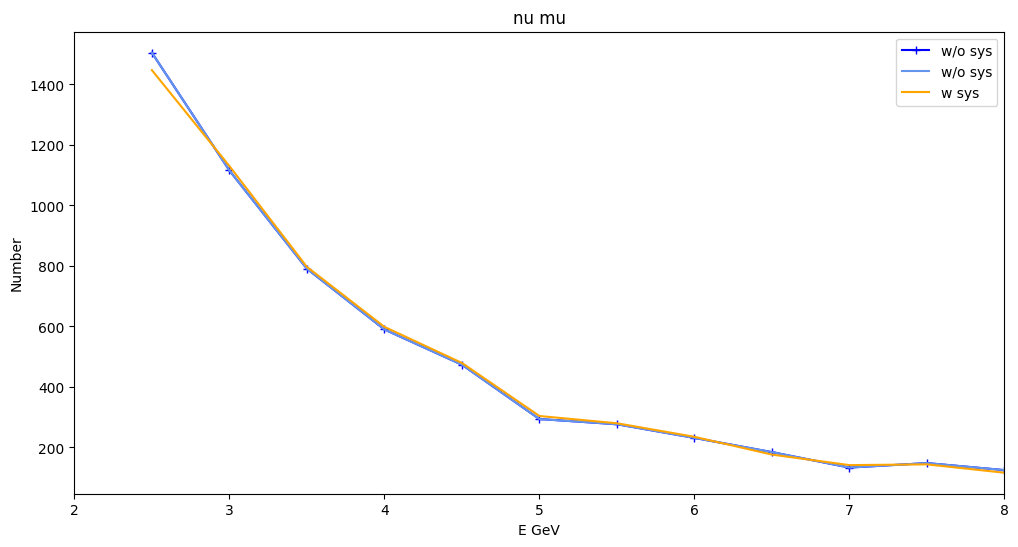

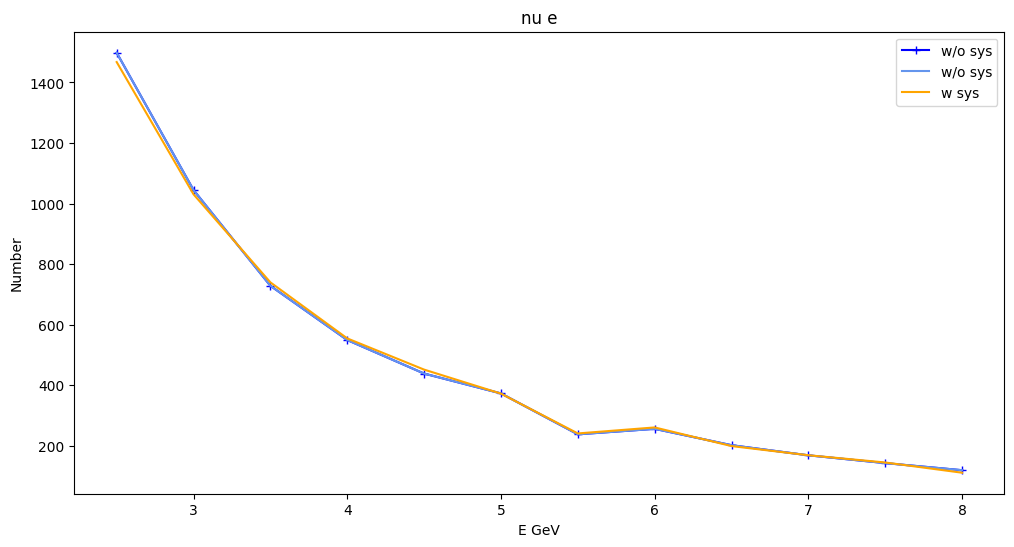

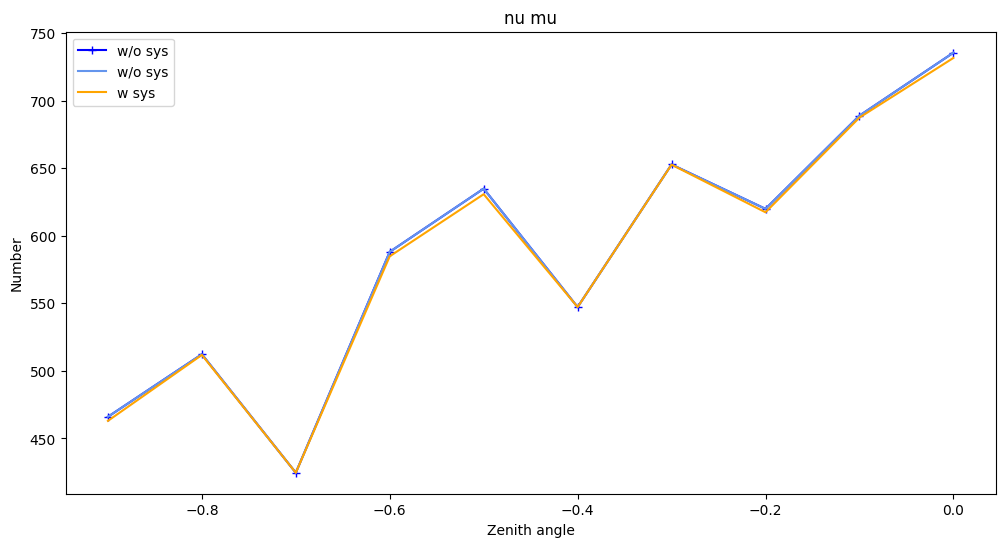

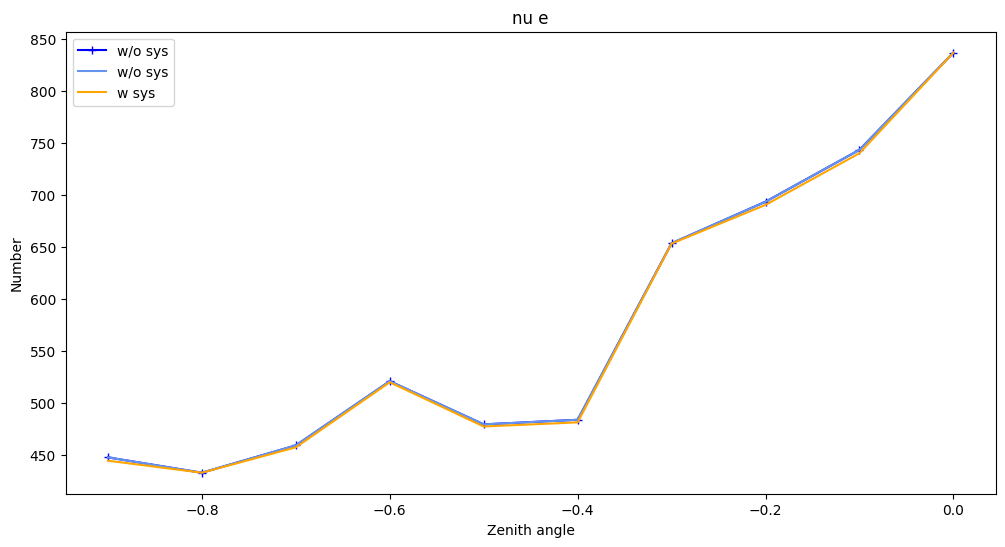

In [ ]:
################################### plots to check Energy and Direction shifts are working ################################
inv_pars = get_nufit(MH.Inverted)
norm_pars = get_nufit(MH.Normal)



events.compute_osc(norm_pars)
events2.compute_osc(norm_pars)
toyevents.compute_osc(norm_pars)
        

events_mu = events.get_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuMu, True) 
events_e = events.get_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuE, True)

events2_mu = events2.get_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuMu, True)
events2_e = events2.get_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuE, True)

toy_mu = toyevents.get_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuMu, True)
toy_e = toyevents.get_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuE, True)

print("events mu :" + str(np.sum(events_mu)) + " e: " + str(np.sum(events_e)))
print("events2 mu :" + str(np.sum(events2_mu)) + " e: " + str(np.sum(events2_e)))
print("toy mu :" + str(np.sum(toy_mu)) + " e: " + str(np.sum(toy_e)))


fig1=plt.figure(figsize=(12,6))
plt.plot(Ebins_reco[1:], events_mu.sum(axis=0).todense(), label="w/o sys", color='blue', marker='+') 
#plt.xscale('log')
plt.plot(Ebins_reco[1:], events2_mu.sum(axis=0).todense(), label="w/o sys", color='cornflowerblue') 
plt.plot(Ebins_reco[1:], toy_mu.sum(axis=0).todense(), label="w sys",color='orange')
plt.title("nu mu")
plt.xlabel("E GeV")
plt.ylabel("Number")
plt.xlim(2,8)
plt.legend()

fig2=plt.figure(figsize=(12,6))
plt.plot(Ebins_reco[1:], events_e.sum(axis=0).todense(), label="w/o sys", color='blue', marker='+') 
#plt.xscale('log')
plt.plot(Ebins_reco[1:], events2_e.sum(axis=0).todense(), label="w/o sys", color='cornflowerblue') 
plt.plot(Ebins_reco[1:], toy_e.sum(axis=0).todense(), label="w sys", color='orange')
plt.title("nu e")
plt.xlabel("E GeV")
plt.ylabel("Number")
plt.legend()

fig3=plt.figure(figsize=(12,6))
plt.plot(Czbins_reco[1:], events_mu.sum(axis=1).todense(), label="w/o sys", color='blue',marker='+') 
plt.plot(Czbins_reco[1:], events2_mu.sum(axis=1).todense(), label="w/o sys", color='cornflowerblue') 
plt.plot(Czbins_reco[1:], toy_mu.sum(axis=1).todense(), label="w sys",color='orange')
plt.title("nu mu")
plt.xlabel("Zenith angle")
plt.ylabel("Number")
plt.legend()

fig4=plt.figure(figsize=(12,6))
plt.plot(Czbins_reco[1:], events_e.sum(axis=1).todense(), label="w/o sys", color='blue', marker='+') 
plt.plot(Czbins_reco[1:], events2_e.sum(axis=1).todense(), label="w/o sys", color='cornflowerblue') 
plt.plot(Czbins_reco[1:], toy_e.sum(axis=1).todense(), label="w sys", color='orange')
plt.title("nu e")
plt.xlabel("Zenith angle")
plt.ylabel("Number")
plt.legend()

{<Flavor.NuTauBar: -16>: <COO: shape=(10, 12), dtype=float64, nnz=117, fill_value=0.0>, <Flavor.NuMuBar: -14>: <COO: shape=(10, 12), dtype=float64, nnz=120, fill_value=0.0>, <Flavor.NuEBar: -12>: <COO: shape=(10, 12), dtype=float64, nnz=120, fill_value=0.0>, <Flavor.NuE: 12>: <COO: shape=(10, 12), dtype=float64, nnz=120, fill_value=0.0>, <Flavor.NuMu: 14>: <COO: shape=(10, 12), dtype=float64, nnz=120, fill_value=0.0>, <Flavor.NuTau: 16>: <COO: shape=(10, 12), dtype=float64, nnz=120, fill_value=0.0>}
12
22.64875567307281 119
14
22.57360871578686 114
-16
16
-14
-12


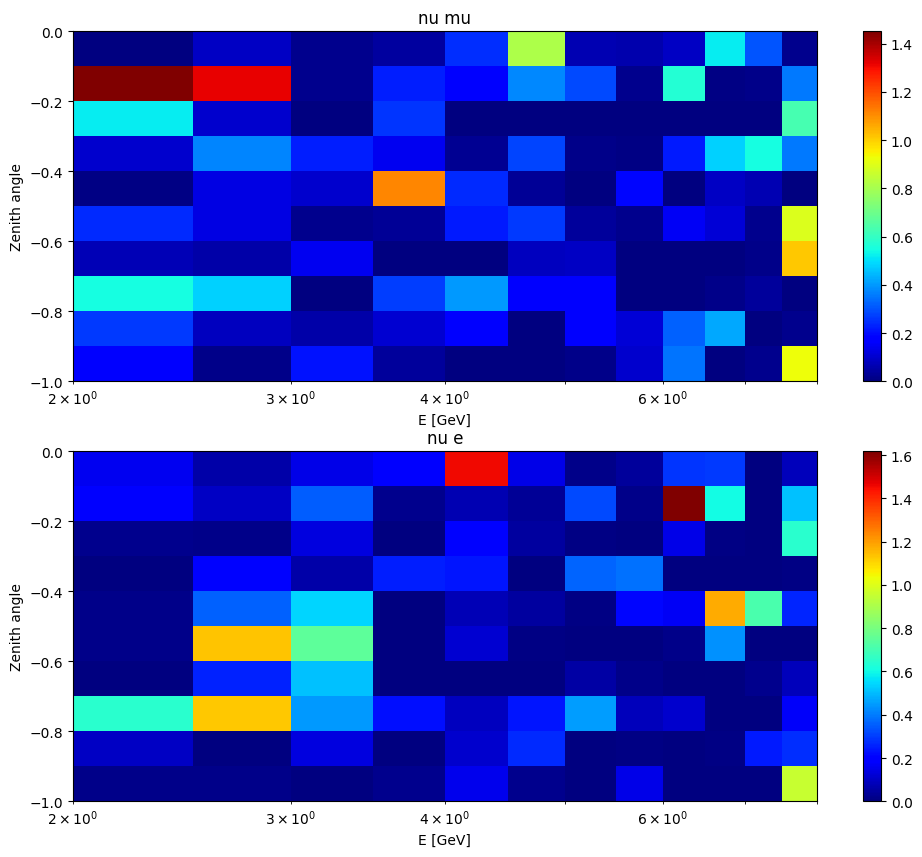

In [ ]:


################################### plots to check chi2.. ################################

def chi2vals(observed, expected):
    
    with np.errstate(divide='ignore', invalid='ignore'):
    
        chi2 = np.where(expected > 0,
                     ( expected - observed )**2/expected,
                      0) 
        
        
        sum = np.sum(chi2)
        dof = len(chi2.data)
        print(sum,dof)
    return chi2

inv_pars = get_nufit(MH.Inverted)
norm_pars = get_nufit(MH.Normal)
inv_pars.dcp = np.pi
norm_pars.dcp =np.pi


events.compute_osc(norm_pars)
events2.compute_osc(norm_pars)
toyevents.compute_osc(norm_pars)
        
obs_events = {fl: events.detected_events(fl) for fl in events.detected_channels}
obs_events2 = {fl: events2.detected_events(fl) for fl in events2.detected_channels}
obs_toyevents = {fl: toyevents.detected_events(fl) for fl in toyevents.detected_channels}
         
print(obs_events)
common_keys = obs_events.keys() & obs_events2.keys() & obs_toyevents.keys()

fig1=plt.figure(figsize=(12,10))

for k in common_keys:
    if k == Flavor.NC:
        continue
    print(k)
    if k==Flavor.NuMu:
        plt.subplot(2,1,1)
        #how to check chi2 value --> 
        #need colour scale...
        plt.pcolormesh(Ebins_reco, Czbins_reco, chi2vals(obs_events[k], obs_toyevents[k]).todense()  , cmap='jet')
        plt.xscale('log')
        plt.title("nu mu")
        plt.xlabel("E [GeV]")
        plt.ylabel("Zenith angle") 
        plt.colorbar()
      

    if k==Flavor.NuE:
        plt.subplot(2,1,2)
        plt.pcolormesh(Ebins_reco, Czbins_reco, chi2vals(obs_events[k], obs_toyevents[k]).todense()  , cmap='jet')
        plt.xscale('log')
        plt.title("nu e")
        plt.xlabel("E [GeV]")
        plt.ylabel("Zenith angle")   
        plt.colorbar()
   



resolution events : 
- E : 0.0% 
- Cz : 26.17993877991494%
time : 0.033576011657714844
resolution events2 : 
- E : 0.0% 
- Cz : 34.906585039886586%


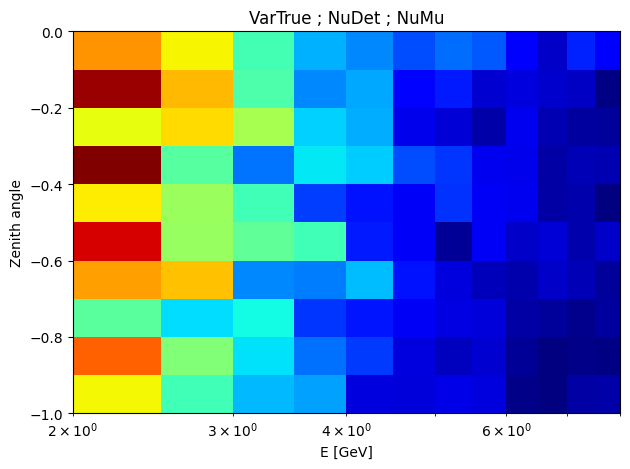

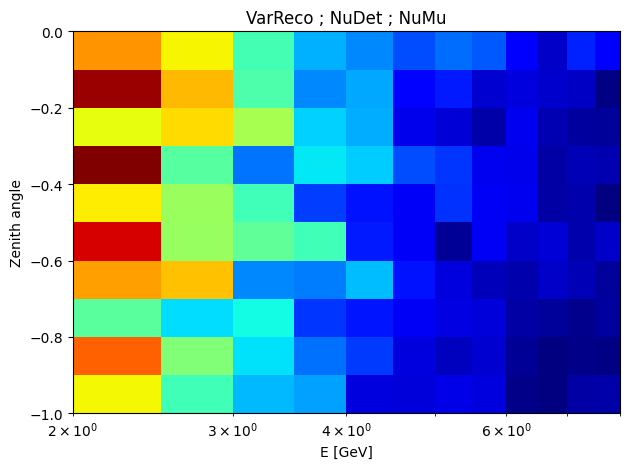

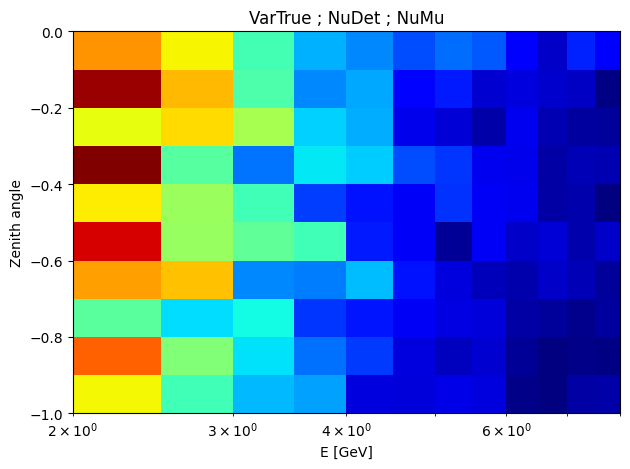

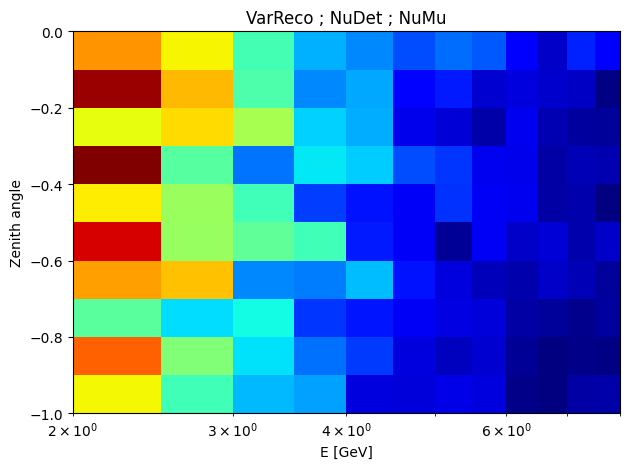

In [ ]:
#Plotting some event distributions
pars = get_nufit(MH.Normal)
events.compute_osc(pars)
fig1 = events.plot_distrib(VarType.VarTrue, NuAxis.NuDet, Flavor.NuMu, oscillated=True)
fig2 = events.plot_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuMu, oscillated=True)
print(f"resolution events : \n- E : {Eres_events*100}% \n- Cz : {Czres_events*100}%")

start = time.time()
events2.compute_osc(pars)
print("time :",time.time()-start)
fig3 = events2.plot_distrib(VarType.VarTrue, NuAxis.NuDet, Flavor.NuMu, oscillated=True)
fig4 = events2.plot_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuMu, oscillated=True)
print(f"resolution events2 : \n- E : {Eres_events2*100}% \n- Cz : {Czres_events2*100}%")


Choose the parameter on which to scan

In [ ]:
class Scan(IntEnum) :
    Dcp = 0
    Th23 = 1

latex_scan = {
    Scan.Dcp : r"$\delta_{CP}$",
    Scan.Th23 : r"$\sin^2  \theta_{23}$"
}

scan = Scan.Th23

print("ok")

ok


In [ ]:
if False :
    from tqdm import tqdm

    # Get Mass Heirarchy sensitivity comparing events to testevents [inc sys]

    if scan == Scan.Dcp:        # scanning dcp value
        sampling = np.linspace(np.pi/2.0, 3.0*np.pi/2.0, 10) #10 
        #np.linspace(0,2*np.pi,3) #sampling dcp values pi/2,  3pi/2, interesting values

    elif scan == Scan.Th23:     # scan on sin² th23 value
        sampling = np.linspace(0.4,0.6,10)
        

    for i,E in enumerate(Ebins_reco):
        if(E>=0.5):
            threshold=i
            break
    print("threshold at "+str(threshold))   

    
    def myLnL(indata,inmc):
    
        data = indata[threshold:len(indata)]
        mc   = inmc[threshold:len(inmc)]
                            # Ebins_reco = np.logspace(-1, 1, 50) #threshold 0.5 GeV                                              
        with np.errstate(divide='ignore', invalid='ignore'):
            
    #        where(condition, if_true, if_false)
            llh = np.where(mc > 0,
                np.where(data > 0,  
                (mc - data + data*np.log(data/mc)),
                mc),
                np.where(data > 0, -1*data, 0)
                )
        #swap with ch2 to check -- chi2 values 2500 
        #   chi2 = np.where(mc > 0,
        #                 ( mc - data )**2/mc,
        #                  0) 
            
            
        #  sum = np.sum(chi2)
        #  dof = len(chi2.data)
        #  print(sum,dof)        
    #    dof = len(llh.data)
        sum=np.sum(llh)
    #    print(sum, dof)
        
        return sum

    def GetLNL(refevents, testevents, refpars, testpars  ):
    
        
        LnL_values = {fl: [] for fl in refevents.detected_channels}
    

        for val in tqdm(sampling):
                if scan == Scan.Dcp :
                    testpars.dcp = val
                    refpars.dcp = val
                elif scan == Scan.Th23 :
                    testpars.th23 = np.arcsin(np.sqrt(val))
                    refpars.th23 = np.arcsin(np.sqrt(val))

                refevents.compute_osc(refpars)
                #Saving the reference event rates
                ref_event_rates = {fl: refevents.detected_events(fl) for fl in refevents.detected_channels}
                #Compute the events with inverted ordering
                testevents.compute_osc(testpars)
                #Save the test event rates
                test_event_rates = {fl: testevents.detected_events(fl) for fl in testevents.detected_channels}
                
            
                #Computing the LnL values for
                for ch in testevents.detected_channels:
                #  print(ch)
                    LnL_values[ch].append(myLnL(np.array(test_event_rates[ch].todense()), np.array(ref_event_rates[ch].todense())))
                    
        return LnL_values


    ##############################################
        #Gets the standard oscillation parameters
    inv_pars = get_nufit(MH.Inverted)
    norm_pars = get_nufit(MH.Normal)

    #used for testing true normal hierarchy -- use wrong dm31, th13 (small), but fix th23 as for Normal
    #norm_wpars = get_nufit(MH.Inverted)
    #norm_wpars.th23 = np.arcsin(np.sqrt(0.452))
    norm_wpars = get_nufit(MH.Normal)
    norm_wpars.dm31 = -2.449E-3 + norm_wpars.dm21

    #used for testing true inverted hierarchy -- use wrong dm31, small effect on th13, but fix th23 as for Inverted
    inv_wpars = get_nufit(MH.Inverted) #use these parameters when calculating wrong hierarchy
    #inv_wpars.th23 = np.arcsin(np.sqrt(0.579))
    inv_wpars.dm31 = 2.457E-3

    if scan == Scan.Th23 :
        inv_pars.dcp = 0
        inv_wpars.dcp = 0
        norm_pars.dcp = 0
        norm_wpars.dcp = 0

        
        inv_pars.dm21 = 7.55e-5
        inv_wpars.dm21 = 7.55e-5
        norm_pars.dm21 = 7.55e-5
        norm_wpars.dm21 = 7.55e-5

        inv_pars.dm31 = -2.42e-3
        inv_wpars.dm31 = 2.5e-3
        norm_pars.dm31 = 2.5e-3
        norm_wpars.dm31 = -2.42e-3


        inv_pars.th12 = np.arcsin(np.sqrt(0.32))
        inv_wpars.th12 = np.arcsin(np.sqrt(0.32))
        norm_pars.th12 = np.arcsin(np.sqrt(0.32))
        norm_wpars.th12 = np.arcsin(np.sqrt(0.32))

        inv_pars.th13 = np.arcsin(np.sqrt(0.0222))
        inv_wpars.th13 = np.arcsin(np.sqrt(0.0222))
        norm_pars.th13 = np.arcsin(np.sqrt(0.0216))
        norm_wpars.th13 = np.arcsin(np.sqrt(0.0216))
        
        



    # Get the log-likelyhoods


    LnL_values_norm = GetLNL(events, toyevents, norm_pars, norm_pars)  
    LnL_values_norm_wrongH = GetLNL(events, toyevents, norm_wpars, norm_pars)
    LnL_values_inv= GetLNL(events, toyevents, inv_pars, inv_pars)
    LnL_values_inv_wrongH = GetLNL(events, toyevents, inv_wpars, inv_pars)

    #
    #Converting the lists to numpy arrays
    LnL_values_norm = {fl: np.array(values) for fl, values in LnL_values_norm.items()}
    LnL_values_inv = {fl: np.array(values) for fl, values in LnL_values_inv.items()}
    LnL_values_norm_wrongH = {fl: np.array(values) for fl, values in LnL_values_norm_wrongH.items()}
    LnL_values_inv_wrongH = {fl: np.array(values) for fl, values in LnL_values_inv_wrongH.items()}



    ############# perfect values events vs events [for reference]
    perfect_LnL_values_norm = GetLNL(events, events2, norm_pars, norm_pars) #think maybe have the wrong way around ?
    #perfect_LnL_values_norm_wrongH = GetLNL(events, events2, inv_pars, norm_pars)
    perfect_LnL_values_norm_wrongH = GetLNL(events, events2, norm_wpars, norm_pars)

    perfect_LnL_values_inv= GetLNL(events, events2, inv_pars, inv_pars)
    #perfect_LnL_values_inv_wrongH = GetLNL(events, events2, norm_pars, inv_pars)
    perfect_LnL_values_inv_wrongH = GetLNL(events, events2, inv_wpars, inv_pars)
    #
    #Converting the lists to numpy arrays
    perfect_LnL_values_norm = {fl: np.array(values) for fl, values in perfect_LnL_values_norm.items()}
    perfect_LnL_values_inv = {fl: np.array(values) for fl, values in perfect_LnL_values_inv.items()}
    perfect_LnL_values_norm_wrongH = {fl: np.array(values) for fl, values in perfect_LnL_values_norm_wrongH.items()}
    perfect_LnL_values_inv_wrongH = {fl: np.array(values) for fl, values in perfect_LnL_values_inv_wrongH.items()}



In [ ]:
def NpEnv(func):
    def aux(*param):
        curr_err = np.geterr()
        #print(curr_err)
        np.seterr(divide='ignore', invalid='ignore')
        res = func(*param)
        #print(np.geterr())
        np.seterr(**curr_err)
        return res
    return aux

In [ ]:
#np.seterr(divide='ignore', invalid='ignore')
"""
@NpEnv
@jit(cache=True)
def bu(arr):
    #with np.errstate(divide='ignore', invalid='ignore'):
    res = np.where(arr >= 0, arr, -arr)
    mu = res.sum()
    return res

x = np.linspace(0,4,100)
val = np.sin(x*np.pi)

plt.plot(x,val)
plt.plot(x,bu(val))
"""
#np.seterr(**curr_err)

"\n@NpEnv\n@jit(cache=True)\ndef bu(arr):\n    #with np.errstate(divide='ignore', invalid='ignore'):\n    res = np.where(arr >= 0, arr, -arr)\n    mu = res.sum()\n    return res\n\nx = np.linspace(0,4,100)\nval = np.sin(x*np.pi)\n\nplt.plot(x,val)\nplt.plot(x,bu(val))\n"

In [ ]:
from tqdm import tqdm

# Get Mass Heirarchy sensitivity comparing events to testevents [inc sys]

if scan == Scan.Dcp:        # scanning dcp value
    sampling = np.linspace(np.pi/2.0, 3.0*np.pi/2.0, 10) #10 
    #np.linspace(0,2*np.pi,3) #sampling dcp values pi/2,  3pi/2, interesting values

elif scan == Scan.Th23:     # scan on sin² th23 value
    sampling = np.linspace(0.4,0.6,10)
     

for i,E in enumerate(Ebins_reco):
    if(E>=0.5):
        threshold=i
        break
print("threshold at "+str(threshold))   

#@chrono
def myLnL(indata,inmc):
   
    data = indata[threshold:len(indata)]
    mc   = inmc[threshold:len(inmc)]
    #print(data.min(),data.max())
    #print(mc.min(),mc.max())
                         # Ebins_reco = np.logspace(-1, 1, 50) #threshold 0.5 GeV                                              
    with np.errstate(divide='ignore', invalid='ignore'):
        
#        where(condition, if_true, if_false)
        llh = np.where(mc > 0,
              np.where(data > 0,  (mc - data + data*np.log(data/mc)), mc),
              np.where(data > 0, -1*data, 0)
               )
    sum=np.sum(llh)
    return sum

def GetLNL(refevents, testevents, refpars, testpars  ):
   
    
    LnL_values = {fl: [] for fl in refevents.detected_channels}
  

    for val in tqdm(sampling):
            if scan == Scan.Dcp :
                testpars.dcp = val
                refpars.dcp = val
            elif scan == Scan.Th23 :
                testpars.th23 = np.arcsin(np.sqrt(val))
                refpars.th23 = np.arcsin(np.sqrt(val))

            refevents.compute_osc(refpars)
            #Saving the reference event rates
            ref_event_rates = {fl: refevents.detected_events(fl) for fl in refevents.detected_channels}
            #Compute the events with inverted ordering
            testevents.compute_osc(testpars)
            #Save the test event rates
            test_event_rates = {fl: testevents.detected_events(fl) for fl in testevents.detected_channels}
            
           
            #Computing the LnL values for
            for ch in testevents.detected_channels:
                #print(ch, -ch)
                LnL_values[ch].append(myLnL(test_event_rates[ch] + test_event_rates[-ch], ref_event_rates[ch] + ref_event_rates[-ch]))
                #LnL_values[ch].append(myLnL(test_event_rates[ch], ref_event_rates[ch]))
                
    return LnL_values


##############################################
    #Gets the standard oscillation parameters
inv_pars = get_nufit(MH.Inverted)
norm_pars = get_nufit(MH.Normal)

#used for testing true normal hierarchy -- use wrong dm31, th13 (small), but fix th23 as for Normal
#norm_wpars = get_nufit(MH.Inverted)
#norm_wpars.th23 = np.arcsin(np.sqrt(0.452))
norm_wpars = get_nufit(MH.Normal)
norm_wpars.dm31 = -2.449E-3 + norm_wpars.dm21

#used for testing true inverted hierarchy -- use wrong dm31, small effect on th13, but fix th23 as for Inverted
inv_wpars = get_nufit(MH.Inverted) #use these parameters when calculating wrong hierarchy
#inv_wpars.th23 = np.arcsin(np.sqrt(0.579))
inv_wpars.dm31 = 2.457E-3

if scan == Scan.Th23 :
    inv_pars.dcp = 0
    inv_wpars.dcp = 0
    norm_pars.dcp = 0
    norm_wpars.dcp = 0

    
    inv_pars.dm21 = 7.55e-5
    inv_wpars.dm21 = 7.55e-5
    norm_pars.dm21 = 7.55e-5
    norm_wpars.dm21 = 7.55e-5

    inv_pars.dm31 = -2.42e-3
    #inv_wpars.dm31 = 2.42e-3
    inv_wpars.dm31 = 2.5e-3
    norm_pars.dm31 = 2.5e-3
    #norm_wpars.dm31 = -2.5e-3 
    norm_wpars.dm31 = -2.42e-3


    inv_pars.th12 = np.arcsin(np.sqrt(0.32))
    inv_wpars.th12 = np.arcsin(np.sqrt(0.32))
    norm_pars.th12 = np.arcsin(np.sqrt(0.32))
    norm_wpars.th12 = np.arcsin(np.sqrt(0.32))

    inv_pars.th13 = np.arcsin(np.sqrt(0.0222))
    inv_wpars.th13 = np.arcsin(np.sqrt(0.0222))
    norm_pars.th13 = np.arcsin(np.sqrt(0.0216))
    norm_wpars.th13 = np.arcsin(np.sqrt(0.0216))
    
    



# Get the log-likelyhoods

LnL_values = Manager().dict() # used to get the results from parallel computing

def ThGetLNL(*args,nom):
    res = GetLNL(*args)
    LnL_values[nom] = res

# call to GetLNL using parallel computing
LnL_values_norm_thr = Process(target = ThGetLNL, args = (events, toyevents, norm_pars, norm_pars), kwargs = {"nom" : "norm"})
LnL_values_norm_thr.daemon = True

LnL_values_norm_wrongH_thr = Process(target = ThGetLNL, args = (events, toyevents, norm_wpars, norm_pars), kwargs = {"nom" : "norm_w"})
LnL_values_norm_wrongH_thr.daemon = True

LnL_values_inv_thr = Process(target = ThGetLNL, args = (events, toyevents, inv_pars, inv_pars), kwargs = {"nom" : "inv"})
LnL_values_inv_thr.daemon = True

LnL_values_inv_wrongH_thr = Process(target = ThGetLNL, args = (events, toyevents, inv_wpars, inv_pars), kwargs = {"nom" : "inv_w"})
LnL_values_inv_wrongH_thr.daemon = True



perfect_LnL_values_norm_thr = Process(target = ThGetLNL, args = (events, events2, norm_pars, norm_pars), kwargs = {"nom" : "perf_norm"})
perfect_LnL_values_norm_thr.daemon = True

perfect_LnL_values_norm_wrongH_thr = Process(target = ThGetLNL, args = (events, events2, norm_wpars, norm_pars), kwargs = {"nom" : "perf_norm_w"})
perfect_LnL_values_norm_wrongH_thr.daemon = True

perfect_LnL_values_inv_thr = Process(target = ThGetLNL, args = (events, events2, inv_pars, inv_pars), kwargs = {"nom" : "perf_inv"})
perfect_LnL_values_inv_thr.daemon = True

perfect_LnL_values_inv_wrongH_thr = Process(target = ThGetLNL, args = (events, events2, inv_wpars, inv_pars), kwargs = {"nom" : "perf_inv_w"})
perfect_LnL_values_inv_wrongH_thr.daemon = True


# start the parallel computing
LnL_values_norm_thr.start()
LnL_values_norm_wrongH_thr.start()
LnL_values_inv_thr.start()
LnL_values_inv_wrongH_thr.start()

perfect_LnL_values_norm_thr.start()
perfect_LnL_values_norm_wrongH_thr.start()
perfect_LnL_values_inv_thr.start()
perfect_LnL_values_inv_wrongH_thr.start()



LnL_values_norm_thr.join()
LnL_values_norm_wrongH_thr.join()
LnL_values_inv_thr.join()
LnL_values_inv_wrongH_thr.join()

perfect_LnL_values_norm_thr.join()
perfect_LnL_values_norm_wrongH_thr.join()
perfect_LnL_values_inv_thr.join()
perfect_LnL_values_inv_wrongH_thr.join()

# get the results of the parallel computing
LnL_values_norm = LnL_values["norm"]
LnL_values_norm_wrongH = LnL_values["norm_w"]
LnL_values_inv = LnL_values["inv"]
LnL_values_inv_wrongH = LnL_values["inv_w"]

#
#Converting the lists to numpy arrays
LnL_values_norm = {fl: np.array(values) for fl, values in LnL_values_norm.items()}
LnL_values_inv = {fl: np.array(values) for fl, values in LnL_values_inv.items()}
LnL_values_norm_wrongH = {fl: np.array(values) for fl, values in LnL_values_norm_wrongH.items()}
LnL_values_inv_wrongH = {fl: np.array(values) for fl, values in LnL_values_inv_wrongH.items()}



############# perfect values events vs events [for reference]

perfect_LnL_values_norm = LnL_values["perf_norm"]
perfect_LnL_values_norm_wrongH = LnL_values["perf_norm_w"]
perfect_LnL_values_inv = LnL_values["perf_inv"]
perfect_LnL_values_inv_wrongH = LnL_values["perf_inv_w"]
#
#Converting the lists to numpy arrays
perfect_LnL_values_norm = {fl: np.array(values) for fl, values in perfect_LnL_values_norm.items()}
perfect_LnL_values_inv = {fl: np.array(values) for fl, values in perfect_LnL_values_inv.items()}
perfect_LnL_values_norm_wrongH = {fl: np.array(values) for fl, values in perfect_LnL_values_norm_wrongH.items()}
perfect_LnL_values_inv_wrongH = {fl: np.array(values) for fl, values in perfect_LnL_values_inv_wrongH.items()}

# terminates processes

LnL_values_norm_thr.terminate()
LnL_values_norm_wrongH_thr.terminate()
LnL_values_inv_thr.terminate()
LnL_values_inv_wrongH_thr.terminate()

perfect_LnL_values_norm_thr.terminate()
perfect_LnL_values_norm_wrongH_thr.terminate()
perfect_LnL_values_inv_thr.terminate()
perfect_LnL_values_inv_wrongH_thr.terminate()



threshold at 0


100%|██████████| 10/10 [00:06<00:00,  1.56it/s]


In [ ]:
LnL_values_norm

{<Flavor.NuTauBar: -16>: array([13.66160814, 13.6599434 , 13.65908515, 13.6590056 , 13.65968794,
        13.66112626, 13.66332554, 13.66630174, 13.67008197, 13.67470476]),
 <Flavor.NuMuBar: -14>: array([11.38205098, 11.47465733, 11.54987633, 11.60604595, 11.64191667,
        11.65669993, 11.65009949, 11.62232302, 11.57407287, 11.50651684]),
 <Flavor.NuEBar: -12>: array([11.49756676, 11.48395855, 11.47115429, 11.45913729, 11.44789122,
        11.43740009, 11.42764831, 11.41862069, 11.41030242, 11.40267908]),
 <Flavor.NuE: 12>: array([11.49756676, 11.48395855, 11.47115429, 11.45913729, 11.44789122,
        11.43740009, 11.42764831, 11.41862069, 11.41030242, 11.40267908]),
 <Flavor.NuMu: 14>: array([11.38205098, 11.47465733, 11.54987633, 11.60604595, 11.64191667,
        11.65669993, 11.65009949, 11.62232302, 11.57407287, 11.50651684]),
 <Flavor.NuTau: 16>: array([13.66160814, 13.6599434 , 13.65908515, 13.6590056 , 13.65968794,
        13.66112626, 13.66332554, 13.66630174, 13.67008197, 1

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] [73.08245176 73.23711857 73.36023154 73.44837768 73.49899167 73.51045256
 73.48214668 73.4144909  73.30891453 73.16780135]
[11.09842029 11.89855651 12.70958953 13.52780248 14.35159276 15.18154691
 16.02043398 16.87311771 17.74639648 18.64878635] [86.14656693 87.09068545 88.00399733 88.88012625 89.71564744 90.51022062
 91.26661057 91.99059393 92.69076131 93.37823164]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] [73.25025517 73.41872993 73.55179839 73.64616957 73.69952313 73.7106068
 73.67929155 73.60657949 73.49456378 73.34634418]
[11.63928131 12.48397208 13.33799998 14.19637699 15.05619184 15.91672456
 16.77948979 17.64820568 18.52869212 19.42870813] [82.00153326 82.95552057 83.89615208 84.81506101 85.7068447  86.56930131
 87.40355447 88.21405492 89.00846054 89.79740781]


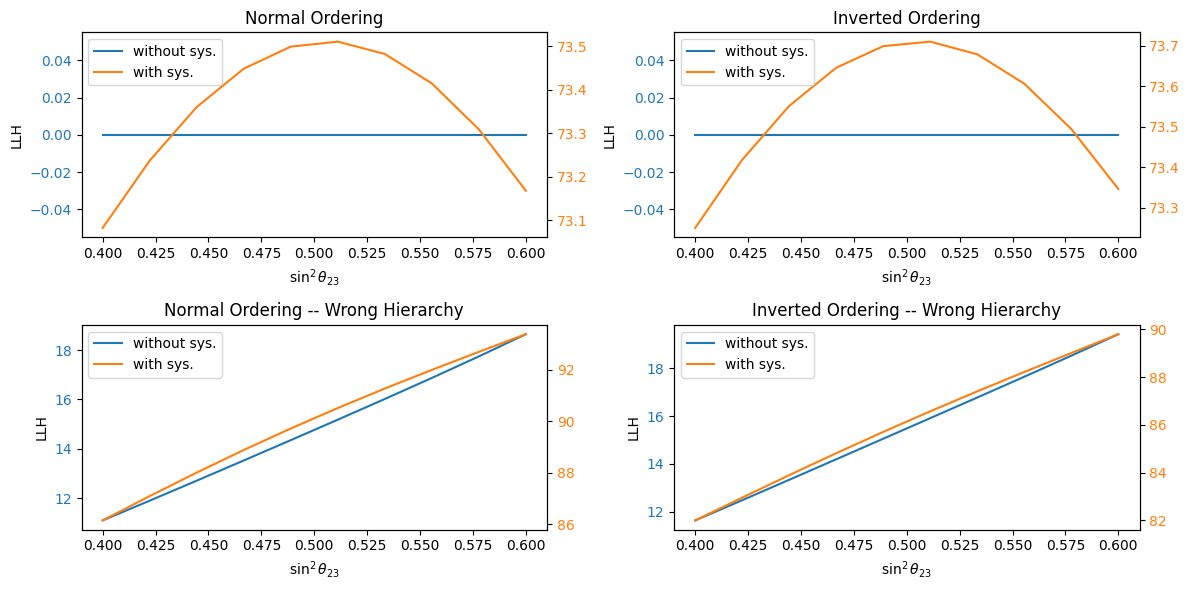

In [ ]:
latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

# PLOT likelihood values obtained

plt.figure(figsize=(12,6))

ax1=plt.subplot(2,2,1)
psum=0
ssum=0
common_keys = LnL_values_norm.keys() & perfect_LnL_values_norm.keys()
for k in common_keys:
    if k == Flavor.NC:
        continue
    psum+=perfect_LnL_values_norm[k]
    ssum+=LnL_values_norm[k]

print(psum,ssum)
wosys = ax1.plot(sampling, psum, label="without sys.", color='tab:blue')
ax1.set_xlabel(latex_scan[scan])
ax1.set_ylabel('LLH')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title("Normal Ordering")
ax1b=ax1.twinx()
wsys = ax1b.plot(sampling, ssum, label='with sys.', color='tab:orange')
ax1b.tick_params(axis='y', labelcolor='tab:orange')
# for legend
lns = wosys + wsys
labs = [l.get_label() for l in lns]
ax1b.legend(lns, labs, loc=2)



ax2=plt.subplot(2,2,3)
psum=0
ssum=0
common_keys = LnL_values_norm_wrongH.keys() & perfect_LnL_values_norm_wrongH.keys()
for k in common_keys:
    if k == Flavor.NC:
        continue
    psum+=perfect_LnL_values_norm_wrongH[k]
    ssum+=LnL_values_norm_wrongH[k]
print(psum,ssum)
wosys = ax2.plot(sampling, psum, label="without sys.", color='tab:blue')
ax2.set_xlabel(latex_scan[scan])
ax2.set_ylabel('LLH')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_title("Normal Ordering -- Wrong Hierarchy")
ax2b=ax2.twinx()
wsys = ax2b.plot(sampling, ssum, label='with sys.', color='tab:orange')
ax2b.tick_params(axis='y', labelcolor='tab:orange')
# for legend
lns = wosys + wsys
labs = [l.get_label() for l in lns]
ax2b.legend(lns, labs, loc=2)

ax3=plt.subplot(2,2,2)
psum=0
ssum=0
common_keys = LnL_values_inv.keys() & perfect_LnL_values_inv.keys()
for k in common_keys:
    if k == Flavor.NC:
        continue

    psum+=perfect_LnL_values_inv[k]
    ssum+=LnL_values_inv[k]
print(psum,ssum)
wosys = ax3.plot(sampling, psum, label="without sys.", color='tab:blue')
ax3.set_xlabel(latex_scan[scan])
ax3.set_ylabel('LLH')
ax3.tick_params(axis='y', labelcolor='tab:blue')
ax3.set_title("Inverted Ordering")
ax3b=ax3.twinx()
wsys = ax3b.plot(sampling, ssum, label='with sys.', color='tab:orange')
ax3b.tick_params(axis='y', labelcolor='tab:orange')
# for legend
lns = wosys + wsys
labs = [l.get_label() for l in lns]
ax3b.legend(lns, labs, loc=2)




ax4=plt.subplot(2,2,4)
psum=0
ssum=0
common_keys = LnL_values_inv_wrongH.keys() & perfect_LnL_values_inv_wrongH.keys()
for k in common_keys:
    if k == Flavor.NC:
        continue
    psum+=perfect_LnL_values_inv_wrongH[k]
    ssum+=LnL_values_inv_wrongH[k]
print(psum,ssum)
wosys = ax4.plot(sampling, psum, label="without sys.", color='tab:blue')
ax4.set_xlabel(latex_scan[scan])
ax4.set_ylabel('LLH')
ax4.tick_params(axis='y', labelcolor='tab:blue')
ax4.set_title("Inverted Ordering -- Wrong Hierarchy")
ax4b=ax4.twinx()
wsys = ax4b.plot(sampling, ssum, label='with sys.', color='tab:orange')
ax4b.tick_params(axis='y', labelcolor='tab:orange')
# for legend
lns = wosys + wsys
labs = [l.get_label() for l in lns]
ax4b.legend(lns, labs, loc=2)
    

plt.tight_layout()      # So that the axis labels won't overlap


In [ ]:
def plot_sens(lnl_val1, lnl_val2):
    common_keys = lnl_val1.keys() & lnl_val2.keys()
    ssum=0
    for k in common_keys:
        if k == Flavor.NC:
        # if k not in [Flavor.NuMu, Flavor.NuMuBar]:
            continue
        deltaLLH = 2*(lnl_val2[k] - lnl_val1[k]) 
        ssum += deltaLLH
    ssum=np.clip(ssum,0,10000)  
    ssum=np.sqrt(ssum/2)
    return ssum

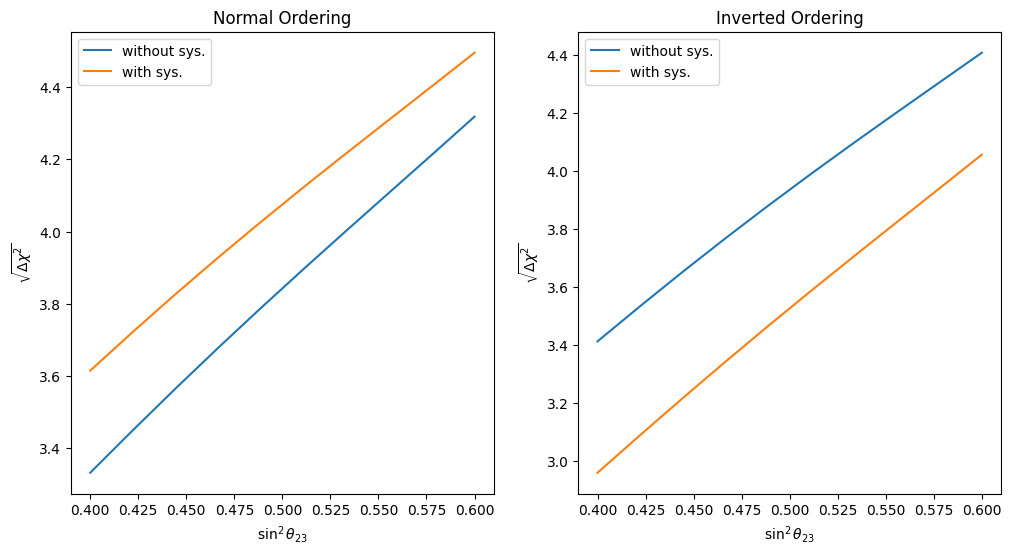

In [ ]:
latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

# PLOT Mass Hierarchy sensitivity

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(sampling, plot_sens(perfect_LnL_values_norm,perfect_LnL_values_norm_wrongH), label="without sys.")
plt.plot(sampling, plot_sens(LnL_values_norm,LnL_values_norm_wrongH), label="with sys.")

plt.xlabel(latex_scan[scan])
plt.ylabel(r'$\sqrt{\Delta \chi^{2}} $ ')
plt.title("Normal Ordering")
plt.legend()
#plt.ylim(3.7,4.4)


plt.subplot(1,2,2)
plt.plot(sampling, plot_sens(perfect_LnL_values_inv,perfect_LnL_values_inv_wrongH), label="without sys.")
plt.plot(sampling, plot_sens(LnL_values_inv,LnL_values_inv_wrongH), label="with sys.")

plt.xlabel(latex_scan[scan])
plt.ylabel(r'$\sqrt{ \Delta \chi^{2}}$')
plt.title("Inverted Ordering")
plt.legend()
#plt.ylim(3.7,4.4)


In [ ]:
if scan == Scan.Th23 :
    print("Values of sin^2 theta_{23} :")
    print("NO :", np.sin(norm_pars.th23)**2)
    print("NO, wh :", np.sin(norm_wpars.th23)**2)
    print("IO :", np.sin(inv_pars.th23)**2)
    print("IO, wh :", np.sin(inv_wpars.th23)**2)

Values of sin^2 theta_{23} :
NO : 0.45199999999999996
NO, wh : 0.45199999999999996
IO : 0.579
IO, wh : 0.579


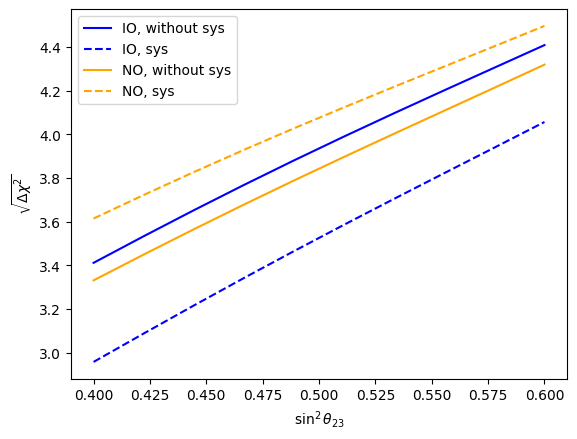

In [ ]:
plt.plot(sampling,plot_sens(perfect_LnL_values_inv,perfect_LnL_values_inv_wrongH),label="IO, without sys",color="blue")
plt.plot(sampling,plot_sens(LnL_values_inv,LnL_values_inv_wrongH),label="IO, sys",color="blue", ls='--')
plt.plot(sampling,plot_sens(perfect_LnL_values_norm,perfect_LnL_values_norm_wrongH),label="NO, without sys",color="orange")
plt.plot(sampling,plot_sens(LnL_values_norm,LnL_values_norm_wrongH),label="NO, sys",color="orange", ls = "--")
plt.xlabel(latex_scan[scan])
plt.ylabel(r"$\sqrt{\Delta \chi^2}$")

#plt.axvline(x=np.sin(norm_wpars.th23)**2,ls='--',label="NO, wh")
#plt.axvline(x=np.sin(inv_wpars.th23)**2,label="IO, wh")

plt.legend()